# GoodAir — Audit & Nettoyage des données
**Fichier source :** `goodair_historique_complet.csv`  
**Colonnes :** id · ville_id · collecte_le · mesure_le · station_timezone · aqi_global · pm25 · pm10 · no2 · o3 · co · so2 · temperature · humidite · pression · vent · polluant_dominant · station_nom · station_url · station_idx · attributions

---
## Plan
1. Chargement & aperçu  
2. Valeurs manquantes  
3. Doublons  
4. Plages de valeurs (validation métier)  
5. Valeurs aberrantes (Z-score & IQR)  
6. Cohérence temporelle  
7. Résumé de l'audit  
8. Nettoyage  
9. Export CSV nettoyé  
10. Comparaison avant / après


## 1. Chargement & aperçu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# ── Style global ──
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (14, 5)

# ── Fichier source ──
FICHIER_SOURCE  = "goodair_historique_complet.csv"
FICHIER_NETTOYE = "goodair_nettoye.csv"
FICHIER_RAPPORT = "audit_rapport.txt"


In [2]:
df = pd.read_csv(FICHIER_SOURCE, sep=";", low_memory=False)

# Conversion des types
for col in ["collecte_le", "mesure_le"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

numeriques = ["aqi_global","pm25","pm10","no2","o3","co","so2",
              "temperature","humidite","pression","vent"]
for col in numeriques:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["ville_id"]    = pd.to_numeric(df["ville_id"], errors="coerce")
df["station_idx"] = pd.to_numeric(df["station_idx"], errors="coerce")

print(f" Fichier chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f" Période        : {df['mesure_le'].min()} → {df['mesure_le'].max()}")
print(f" Villes         : {df['ville_id'].nunique()}")
df.head(3)


 Fichier chargé : 62,664 lignes × 21 colonnes
 Période        : 2026-03-01 00:00:00 → 2026-05-30 23:00:00
 Villes         : 30


,id,ville_id,collecte_le,mesure_le,station_timezone,aqi_global,pm25,pm10,no2,o3,...,so2,temperature,humidite,pression,vent,polluant_dominant,station_nom,station_url,station_idx,attributions
0,1,1,2026-05-31 17:18:40,2026-03-01 00:00:00,NaN,75,2.08,3.11,3.54,62.14,...,0.20,6.1,81,1020.5,2.03,o3,Paris,https://aqicn.org/city/paris,5722,"[{""nom"": ""AirParif - Association de surveillan..."
1,2,1,2026-05-31 17:18:40,2026-03-02 01:00:00,NaN,75,2.02,3.02,2.31,66.04,...,0.13,7.1,79,1014.9,3.00,o3,Paris,https://aqicn.org/city/paris,5722,"[{""nom"": ""AirParif - Association de surveillan..."
2,3,1,2026-05-31 17:18:40,2026-03-02 02:00:00,NaN,75,2.04,2.96,2.06,65.50,...,0.12,6.8,79,1014.5,2.78,o3,Paris,https://aqicn.org/city/paris,5722,"[{""nom"": ""AirParif - Association de surveillan..."


In [3]:
print("\n── Types de colonnes ──")
print(df.dtypes.to_string())
print("\n── Statistiques descriptives ──")
df[numeriques].describe().round(2)



── Types de colonnes ──
id                            int64
ville_id                      int64
collecte_le          datetime64[us]
mesure_le            datetime64[us]
station_timezone            float64
aqi_global                    int64
pm25                        float64
pm10                        float64
no2                         float64
o3                          float64
co                          float64
so2                         float64
temperature                 float64
humidite                      int64
pression                    float64
vent                        float64
polluant_dominant               str
station_nom                     str
station_url                     str
station_idx                   int64
attributions                    str

── Statistiques descriptives ──


,aqi_global,pm25,pm10,no2,o3,co,so2,temperature,humidite,pression,vent
count,62664.00,62664.00,62664.00,62664.00,62664.00,62664.00,62664.00,62664.00,62664.00,62664.00,62664.00
mean,75.03,6.52,9.43,2.60,81.93,139.42,0.58,13.42,68.29,1005.53,2.99
std,24.06,7.66,9.83,3.83,25.62,41.21,0.59,6.14,19.16,15.36,1.82
min,25.00,0.50,0.50,0.08,2.72,69.37,0.02,-3.10,10.00,939.40,0.00
25%,75.00,1.80,3.12,0.70,65.55,117.36,0.20,9.10,54.00,998.50,1.66
50%,75.00,4.17,6.53,1.43,86.21,134.37,0.39,12.60,70.00,1009.50,2.69
75%,100.00,8.18,11.98,2.89,100.41,148.94,0.76,16.90,85.00,1016.30,3.94
max,200.00,96.94,110.19,67.46,169.18,820.99,6.50,36.20,100.00,1033.50,14.19


## 2. Valeurs manquantes

In [4]:
manquantes = pd.DataFrame({
    "colonne":    df.columns,
    "nb_manquants": df.isnull().sum().values,
    "pourcentage":        (df.isnull().mean() * 100).round(2).values
}).query("nb_manquants > 0").sort_values("pourcentage", ascending=False)

print(f"Colonnes avec valeurs manquantes : {len(manquantes)}/{len(df.columns)}")
display(manquantes.reset_index(drop=True).style
    .format({"pourcentage": "{:.1f}%", "nb_manquants": "{:,}"}))


Colonnes avec valeurs manquantes : 1/21


,colonne,nb_manquants,pourcentage
0,station_timezone,"62,664",100.0%


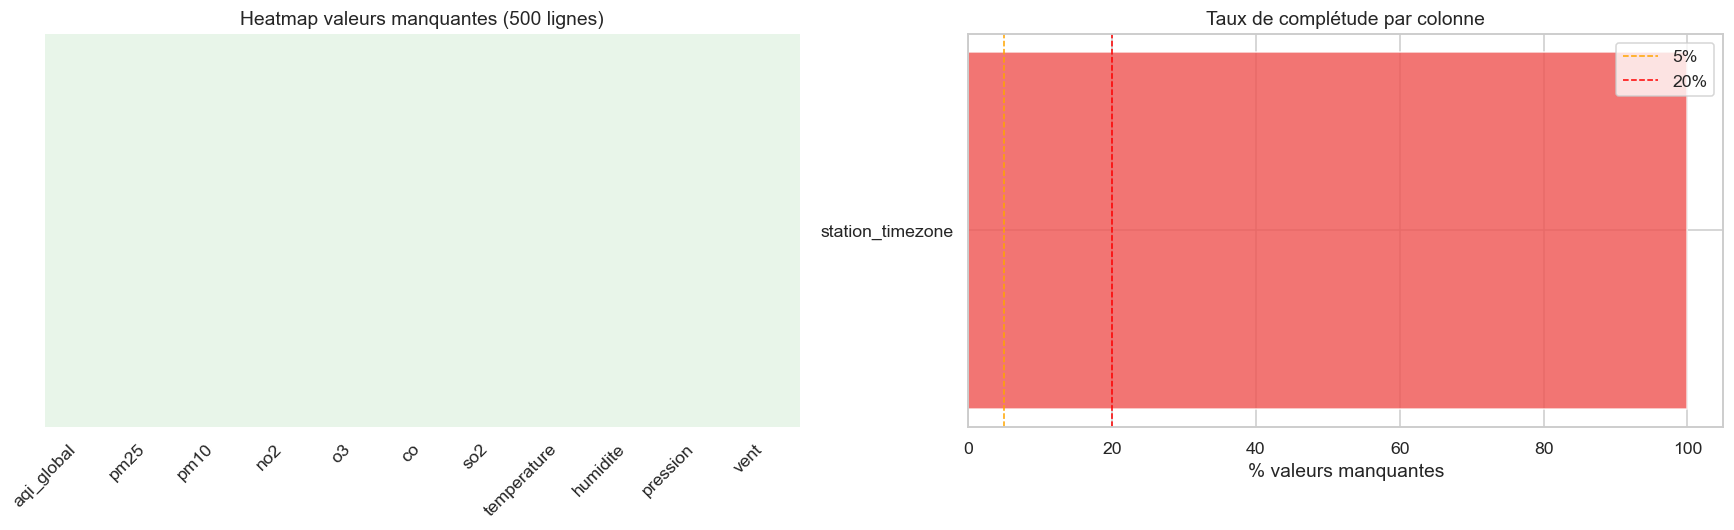

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap (échantillon de 500 lignes pour la lisibilité)
sample = df[numeriques].sample(min(500, len(df)), random_state=42)
sns.heatmap(sample.isnull(), cbar=False, yticklabels=False,
            cmap=["#e8f5e9", "#ef5350"], ax=axes[0])
axes[0].set_title("Heatmap valeurs manquantes (500 lignes)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")

# Barplot % manquants
if len(manquantes):
    axes[1].barh(manquantes["colonne"], manquantes["pourcentage"], color="#ef5350", alpha=0.8)
    axes[1].axvline(5,  color="orange", linestyle="--", linewidth=1, label="5%")
    axes[1].axvline(20, color="red",    linestyle="--", linewidth=1, label="20%")
    axes[1].set_xlabel("% valeurs manquantes")
    axes[1].set_title("Taux de complétude par colonne")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "Aucune valeur manquante ",
                 ha="center", va="center", fontsize=14)

plt.tight_layout()
plt.savefig("audit_manquants.png", bbox_inches="tight")
plt.show()


## 3. Doublons

In [6]:
# Doublons stricts (toutes colonnes identiques)
nb_doublons_stricts = df.duplicated().sum()

# Doublons fonctionnels (même ville + même heure de mesure)
nb_doublons_fonct = df.duplicated(subset=["ville_id","mesure_le"]).sum()

print(f"Doublons stricts          : {nb_doublons_stricts:,}")
print(f"Doublons fonctionnels     : {nb_doublons_fonct:,}  (même ville_id + mesure_le)")

if nb_doublons_fonct > 0:
    dup = df[df.duplicated(subset=["ville_id","mesure_le"], keep=False)]
    print(f"\nExemples de doublons fonctionnels :")
    display(dup.sort_values(["ville_id","mesure_le"])
              .head(6)[["id","ville_id","mesure_le","aqi_global","pm25"]])


Doublons stricts          : 0
Doublons fonctionnels     : 0  (même ville_id + mesure_le)


## 4. Plages de valeurs — validation métier

In [7]:
# Plages attendues selon les standards OMS / AQICN
PLAGES = {
    "aqi_global":  (0,   500, "AQI AQICN"),
    "pm25":        (0,   500, "µg/m³"),
    "pm10":        (0,   600, "µg/m³"),
    "no2":         (0,  2000, "µg/m³"),
    "o3":          (0,   500, "µg/m³"),
    "co":          (0, 50000, "µg/m³"),
    "so2":         (0,  1000, "µg/m³"),
    "temperature": (-60,  60, "°C"),
    "humidite":    (0,   100, "%"),
    "pression":    (870,1084, "hPa"),
    "vent":        (0,   200, "m/s"),
}

lignes_hors_plage = []
for col, (vmin, vmax, unite) in PLAGES.items():
    if col not in df.columns: continue
    hors = df[(df[col] < vmin) | (df[col] > vmax)][col].count()
    pct  = hors / df[col].count() * 100 if df[col].count() > 0 else 0
    obs_min = df[col].min()
    obs_max = df[col].max()
    statut  = "✅" if hors == 0 else ("⚠️" if pct < 1 else "❌")
    lignes_hors_plage.append({
        "colonne": col, "unité": unite,
        "min attendu": vmin, "max attendu": vmax,
        "min observé": round(obs_min, 2) if pd.notna(obs_min) else "NaN",
        "max observé": round(obs_max, 2) if pd.notna(obs_max) else "NaN",
        "hors plage": hors, "% hors plage": round(pct, 2), "statut": statut
    })

df_plages = pd.DataFrame(lignes_hors_plage)
display(df_plages.style
    .map(lambda v: "color:red;font-weight:bold" if v == "❌"
              else ("color:orange" if v == "⚠️" else "color:green"),
              subset=["statut"])
    .format({"% hors plage": "{:.2f}%", "hors plage": "{:,}"}))


,colonne,unité,min attendu,max attendu,min observé,max observé,hors plage,% hors plage,statut
0,aqi_global,AQI AQICN,0,500,25.000000,200.000000,0,0.00%,✅
1,pm25,µg/m³,0,500,0.500000,96.940000,0,0.00%,✅
2,pm10,µg/m³,0,600,0.500000,110.190000,0,0.00%,✅
3,no2,µg/m³,0,2000,0.080000,67.460000,0,0.00%,✅
4,o3,µg/m³,0,500,2.720000,169.180000,0,0.00%,✅
5,co,µg/m³,0,50000,69.370000,820.990000,0,0.00%,✅
6,so2,µg/m³,0,1000,0.020000,6.500000,0,0.00%,✅
7,temperature,°C,-60,60,-3.100000,36.200000,0,0.00%,✅
8,humidite,%,0,100,10.000000,100.000000,0,0.00%,✅
9,pression,hPa,870,1084,939.400000,1033.500000,0,0.00%,✅


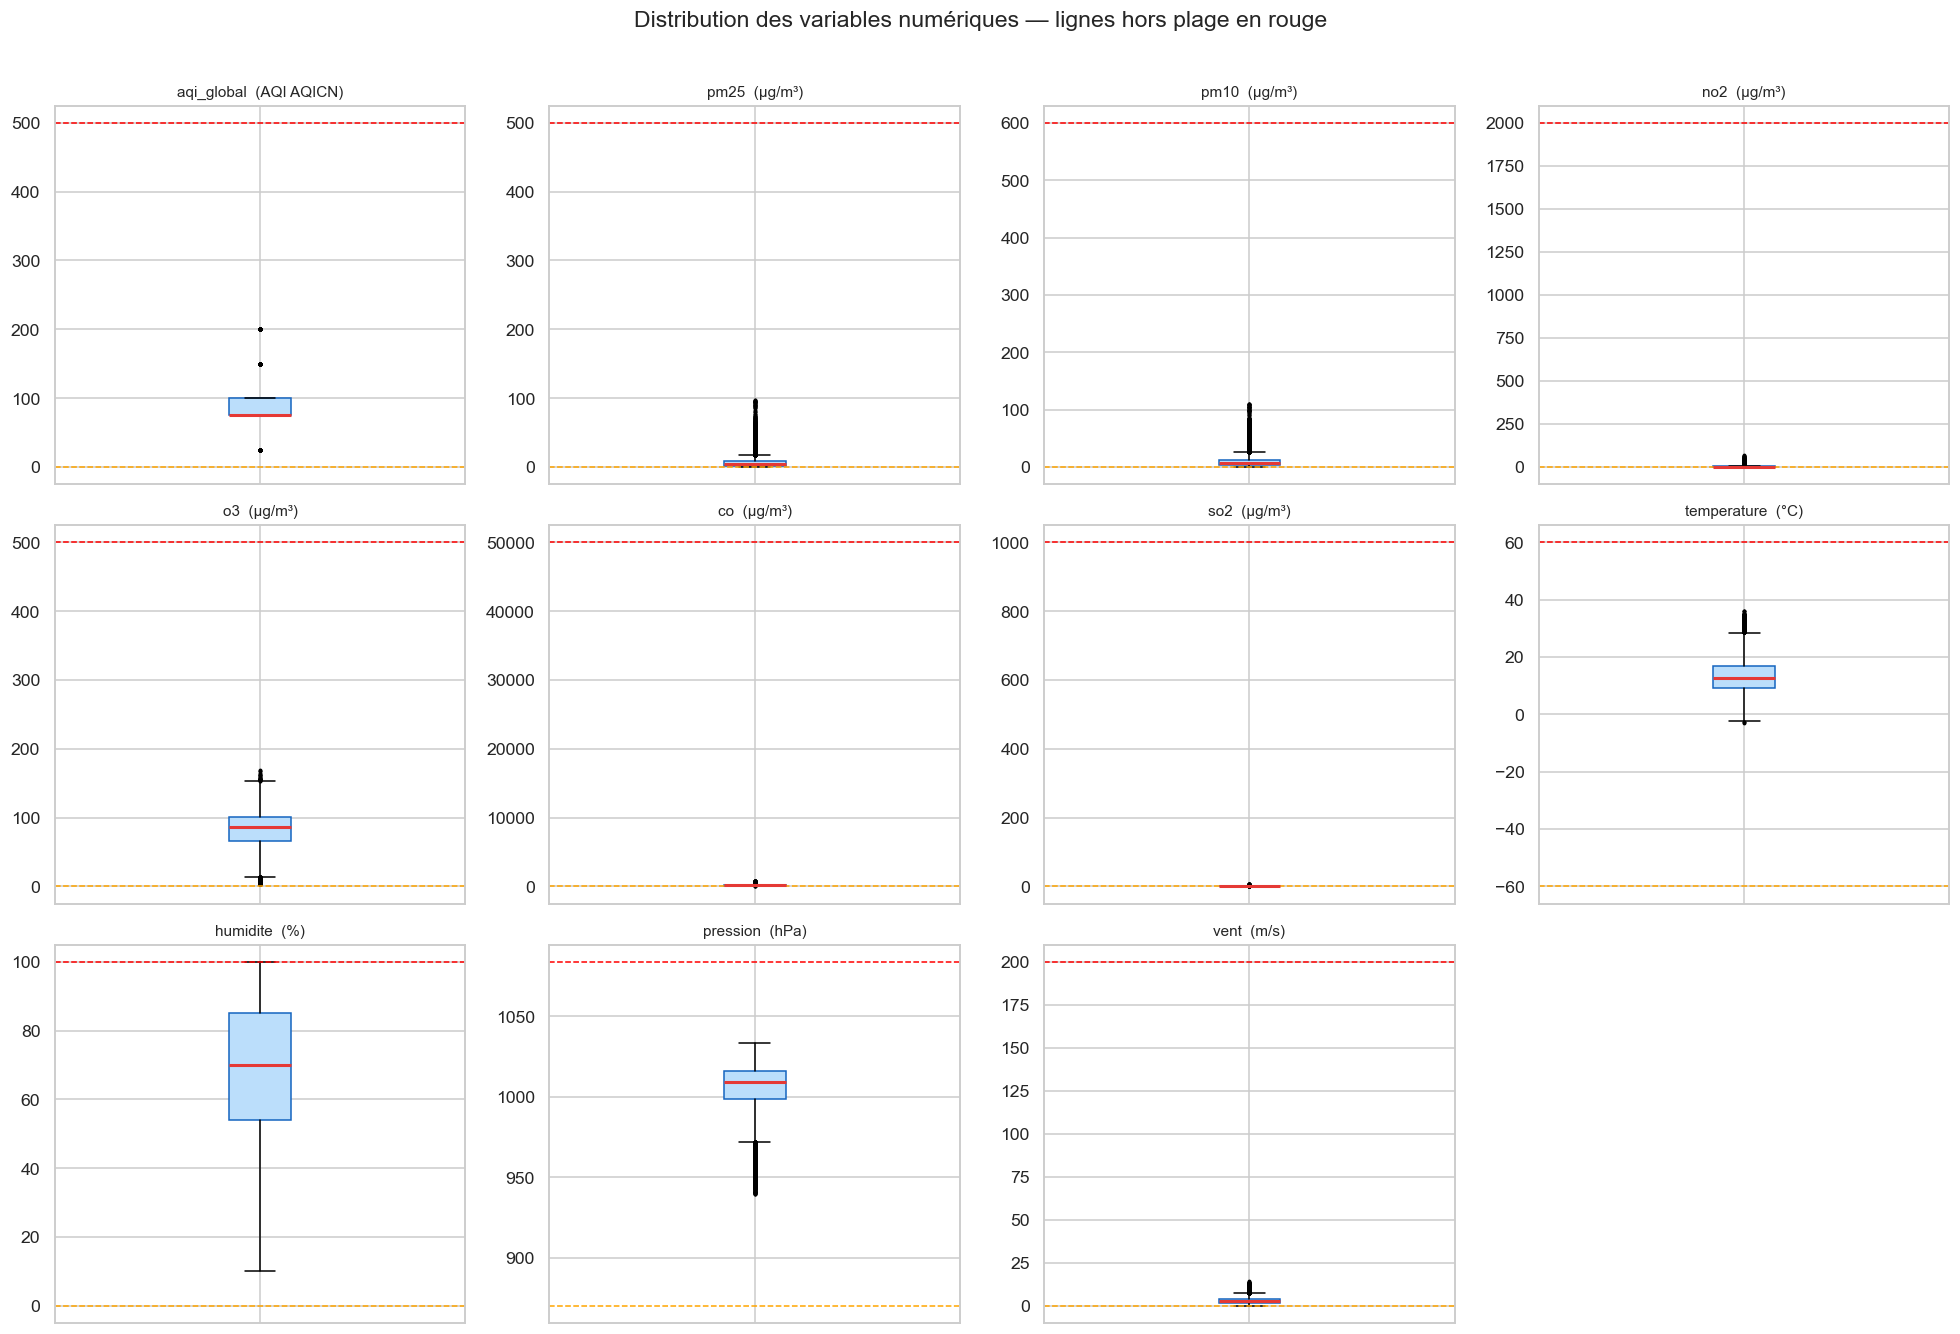

In [8]:
# Boxplots des colonnes numériques
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeriques):
    if col not in df.columns: continue
    vmin, vmax, unite = PLAGES.get(col, (None, None, ""))
    serie = df[col].dropna()
    
    axes[i].boxplot(serie, vert=True, patch_artist=True,
                    boxprops=dict(facecolor="#bbdefb", color="#1565c0"),
                    medianprops=dict(color="#e53935", linewidth=2),
                    flierprops=dict(marker=".", color="#ef9a9a", markersize=3))
    
    if vmin is not None: axes[i].axhline(vmin, color="orange", linestyle="--", linewidth=1)
    if vmax is not None: axes[i].axhline(vmax, color="red",    linestyle="--", linewidth=1, label=f"max={vmax}")
    
    axes[i].set_title(f"{col}  ({unite})", fontsize=10)
    axes[i].tick_params(axis="x", labelbottom=False)

for j in range(len(numeriques), len(axes)): axes[j].set_visible(False)

plt.suptitle("Distribution des variables numériques — lignes hors plage en rouge", y=1.01)
plt.tight_layout()
plt.savefig("audit_distributions.png", bbox_inches="tight")
plt.show()


## 5. Valeurs aberrantes — Z-score & IQR

In [9]:
from scipy import stats

colonnes_outliers = ["aqi_global","pm25","pm10","no2","o3","temperature","vent"]
resultats_outliers = []

for col in colonnes_outliers:
    if col not in df.columns: continue
    serie = df[col].dropna()
    
    # Z-score (seuil > 3)
    z      = np.abs(stats.zscore(serie))
    nb_z   = (z > 3).sum()
    
    # IQR (seuil 1.5×)
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr    = q3 - q1
    nb_iqr = ((serie < q1 - 1.5*iqr) | (serie > q3 + 1.5*iqr)).sum()
    
    resultats_outliers.append({
        "colonne":          col,
        "outliers Z>3":     nb_z,
        "% Z>3":            round(nb_z / len(serie) * 100, 2),
        "outliers IQR×1.5": nb_iqr,
        "% IQR×1.5":        round(nb_iqr / len(serie) * 100, 2),
    })

df_out = pd.DataFrame(resultats_outliers)
display(df_out.style
    .background_gradient(subset=["% Z>3","% IQR×1.5"], cmap="YlOrRd")
    .format({"% Z>3": "{:.2f}%", "% IQR×1.5": "{:.2f}%",
             "outliers Z>3": "{:,}", "outliers IQR×1.5": "{:,}"}))


,colonne,outliers Z>3,% Z>3,outliers IQR×1.5,% IQR×1.5
0,aqi_global,321,0.51%,"9,584",15.29%
1,pm25,"1,363",2.18%,"4,464",7.12%
2,pm10,"1,253",2.00%,"4,177",6.67%
3,no2,"1,369",2.18%,"5,301",8.46%
4,o3,39,0.06%,313,0.50%
5,temperature,332,0.53%,"1,416",2.26%
6,vent,762,1.22%,"1,616",2.58%


Ce tableau ci-dessus montre combien de valeurs aberrantes (outliers) existent dans chaque variable de ton dataset.

Je compare 2 méthodes :
- Z-score: mesure à quel point une valeur est éloignée de la moyenne.
- IQR: écart interquartile. Il mesure l’écart entre: Q1 = 25% des données et Q3 = 75% des données

Exemple pm25 :
- 1363 valeurs PM2.5 sont considérées aberrantes par le Z-score
- cela représente 2.18% des données
- 4464 valeurs sont détectées par IQR
- cela représente 7.12%



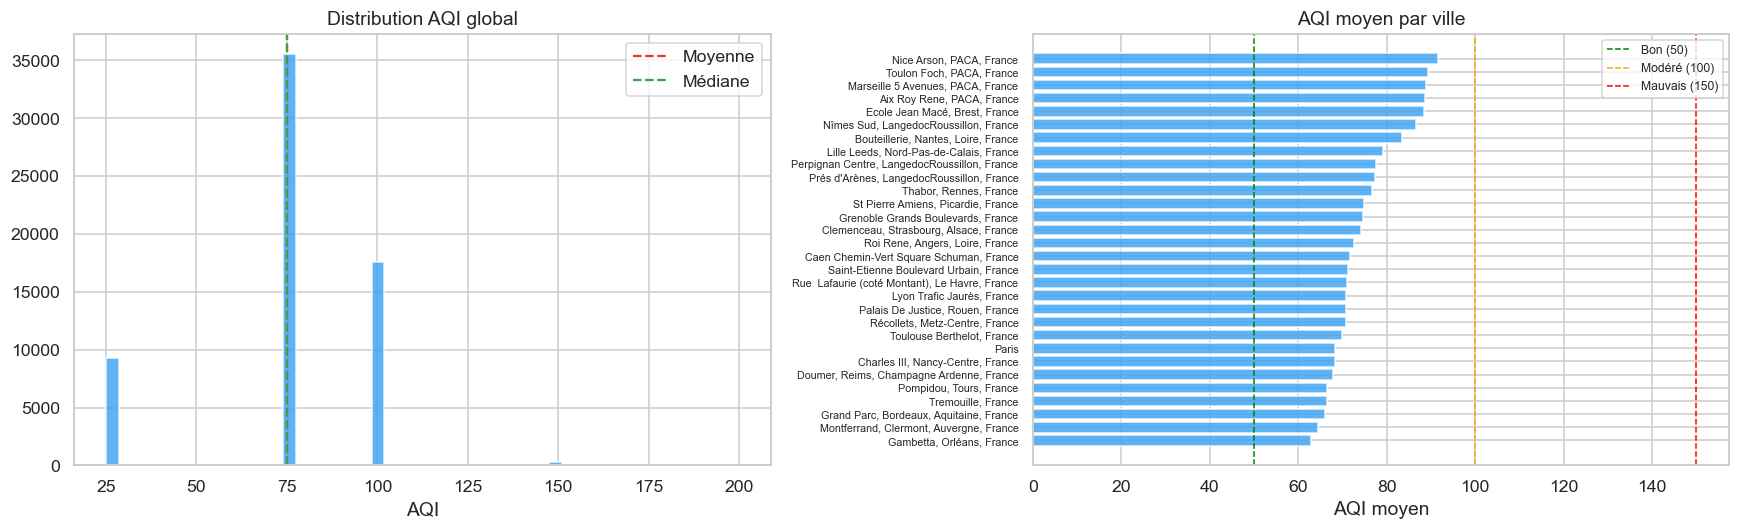

In [10]:
# Z-score par ville pour AQI (détection anomalies locales)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution AQI global
axes[0].hist(df["aqi_global"].dropna(), bins=50, color="#42a5f5", edgecolor="white", alpha=0.85)
axes[0].axvline(df["aqi_global"].mean(),   color="#e53935", linestyle="--", label="Moyenne")
axes[0].axvline(df["aqi_global"].median(), color="#43a047", linestyle="--", label="Médiane")
axes[0].set_title("Distribution AQI global")
axes[0].set_xlabel("AQI")
axes[0].legend()

# AQI moyen par ville
aqi_ville = (df.groupby("station_nom")["aqi_global"]
               .mean()
               .sort_values(ascending=True)
               .dropna())
axes[1].barh(aqi_ville.index, aqi_ville.values, color="#42a5f5", alpha=0.85)
axes[1].axvline(50,  color="green",  linestyle="--", linewidth=1, label="Bon (50)")
axes[1].axvline(100, color="orange", linestyle="--", linewidth=1, label="Modéré (100)")
axes[1].axvline(150, color="red",    linestyle="--", linewidth=1, label="Mauvais (150)")
axes[1].set_title("AQI moyen par ville")
axes[1].set_xlabel("AQI moyen")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig("audit_aqi.png", bbox_inches="tight")
plt.show()


Le graphique ci-dessus analyse la distribution de l’AQI (indice de qualité de l’air)

La moyenne et la médiane de l’AQI global sont très proches et quasiment superposées sur le graphique gauche. Cela indique que la distribution des valeurs est relativement équilibrée, malgré la présence de quelques pics de pollution élevés.

L’analyse des deux graphiques montre que :

la qualité de l’air est globalement modérée dans la majorité des observations,
certaines villes présentent des niveaux de pollution plus élevés,
quelques épisodes ponctuels de forte pollution existent, mais restent minoritaires.

## 6. Cohérence temporelle

In [11]:
# Nombre de mesures attendues par ville
# (1 par heure sur la période = nb_jours × 24)
nb_heures_attendues = int(
    (df["mesure_le"].max() - df["mesure_le"].min()).total_seconds() / 3600
) + 1

completude = (df.groupby("ville_id")["mesure_le"]
                .count()
                .reset_index()
                .rename(columns={"mesure_le": "nb_mesures"}))
completude["attendu"]   = nb_heures_attendues
completude["manquantes"] = completude["attendu"] - completude["nb_mesures"]
completude["completude_%"] = (completude["nb_mesures"] / completude["attendu"] * 100).round(1)

print(f"Heures attendues par ville : {nb_heures_attendues:,}")
print(f"Complétude moyenne         : {completude['completude_%'].mean():.1f}%")
print(f"Ville la moins complète    : {completude['completude_%'].min():.1f}%")

display(completude.sort_values("completude_%").style
    .background_gradient(subset=["completude_%"], cmap="RdYlGn")
    .format({"nb_mesures": "{:,}", "manquantes": "{:,}", "completude_%": "{:.1f}%"}))


Heures attendues par ville : 2,184
Complétude moyenne         : 95.6%
Ville la moins complète    : 95.6%


,ville_id,nb_mesures,attendu,manquantes,completude_%
0,1,"2,088",2184,96,95.6%
1,2,"2,088",2184,96,95.6%
2,3,"2,088",2184,96,95.6%
3,4,"2,088",2184,96,95.6%
4,5,"2,088",2184,96,95.6%
5,6,"2,088",2184,96,95.6%
6,7,"2,088",2184,96,95.6%
7,8,"2,088",2184,96,95.6%
8,9,"2,088",2184,96,95.6%
9,10,"2,088",2184,96,95.6%


Ville id=18 : 72 trous détectés sur 2184 heures


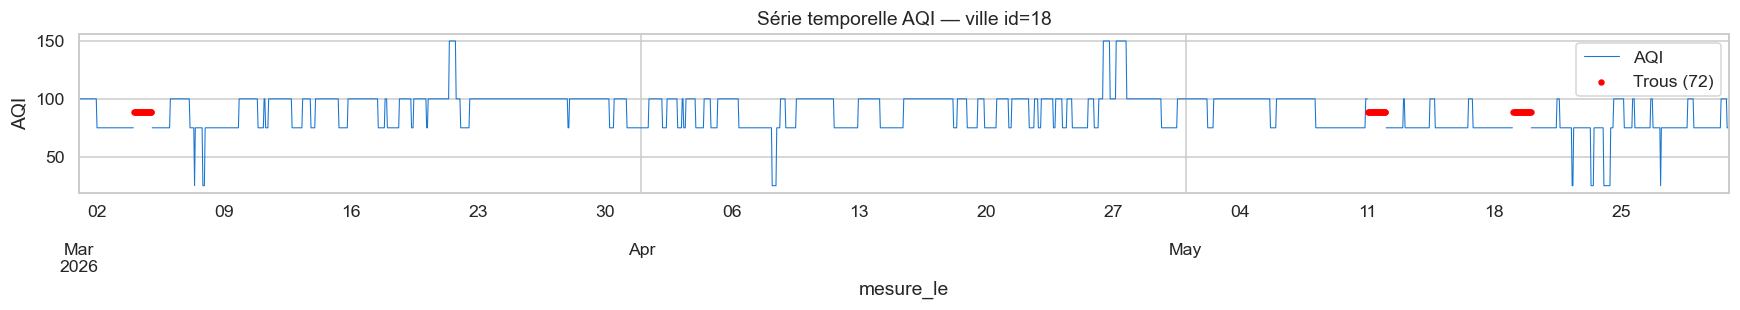

In [12]:
# Détection de trous dans la série temporelle (une ville exemple)
ville_test = df["ville_id"].value_counts().index[0]
serie_ville = (df[df["ville_id"] == ville_test]
                .set_index("mesure_le")["aqi_global"]
                .resample("h").mean())

trous = serie_ville[serie_ville.isna()]
print(f"Ville id={ville_test} : {len(trous)} trous détectés sur {len(serie_ville)} heures")

fig, ax = plt.subplots(figsize=(16, 3))
serie_ville.plot(ax=ax, linewidth=0.7, color="#1976d2", label="AQI")
if len(trous) > 0:
    ax.scatter(trous.index, [serie_ville.mean()]*len(trous),
               color="red", s=10, zorder=5, label=f"Trous ({len(trous)})")
ax.set_title(f"Série temporelle AQI — ville id={ville_test}")
ax.set_ylabel("AQI")
ax.legend()
plt.tight_layout()
plt.savefig("audit_serie_temporelle.png", bbox_inches="tight")
plt.show()


In [13]:
# Localiser tous les trous pour toutes les villes
resultats = []
# Redéfinir la période complète
periode_complete = pd.date_range(
    start=df["mesure_le"].min(),
    end=df["mesure_le"].max(),
    freq="h"
)

for ville in df["ville_id"].unique():
    ville_data = df[df["ville_id"] == ville]["mesure_le"]
    heures_manquantes = periode_complete.difference(ville_data)
    
    for h in heures_manquantes:
        resultats.append({"ville_id": ville, "heure_manquante": h})

df_trous = pd.DataFrame(resultats)

print(f"Total trous : {len(df_trous)}")
print(f"\nRépartition par ville :")
display(df_trous.groupby("ville_id")["heure_manquante"].count()
        .reset_index()
        .rename(columns={"heure_manquante": "nb_trous"}))

print(f"\nDétail des trous (ville 18) :")
display(df_trous[df_trous["ville_id"] == 18]
        .assign(date=lambda x: x["heure_manquante"].dt.date)
        .groupby("date")["heure_manquante"].count()
        .reset_index()
        .rename(columns={"heure_manquante": "nb_heures"}))

Total trous : 2856

Répartition par ville :


,ville_id,nb_trous
0,1,96
1,2,96
2,3,96
3,4,96
4,5,96
5,6,96
6,7,96
7,8,96
8,9,96
9,10,96



Détail des trous (ville 18) :


,date,nb_heures
0,2026-03-04,23
1,2026-03-05,1
2,2026-05-11,23
3,2026-05-12,1
4,2026-05-19,23
5,2026-05-20,1


In [15]:
import requests
from datetime import datetime, timezone

OWM_API_KEY = "651e6c14dbbb2fde75c28d5880f652bf"

VILLES_COORDS = {
    1:  {"lat": 48.8566, "lon":  2.3522},  # Paris
    2:  {"lat": 45.7640, "lon":  4.8357},  # Lyon
    3:  {"lat": 43.2965, "lon":  5.3698},  # Marseille
    4:  {"lat": 43.6047, "lon":  1.4442},  # Toulouse
    5:  {"lat": 44.8378, "lon": -0.5792},  # Bordeaux
    6:  {"lat": 50.6292, "lon":  3.0573},  # Lille
    7:  {"lat": 48.5734, "lon":  7.7521},  # Strasbourg
    8:  {"lat": 43.7102, "lon":  7.2620},  # Nice
    9:  {"lat": 47.2184, "lon": -1.5536},  # Nantes
    10: {"lat": 45.1885, "lon":  5.7245},  # Grenoble
    11: {"lat": 48.1173, "lon": -1.6778},  # Rennes
    12: {"lat": 49.2583, "lon":  4.0317},  # Reims
    13: {"lat": 49.4944, "lon":  0.1079},  # Le Havre
    14: {"lat": 45.4347, "lon":  4.3900},  # Saint-Etienne
    15: {"lat": 43.1242, "lon":  5.9280},  # Toulon
    16: {"lat": 47.4784, "lon": -0.5632},  # Angers
    17: {"lat": 47.3220, "lon":  5.0415},  # Dijon
    18: {"lat": 48.3905, "lon": -4.4860},  # Brest
    19: {"lat": 43.8367, "lon":  4.3601},  # Nimes
    20: {"lat": 43.5297, "lon":  5.4474},  # Aix-en-Provence
    21: {"lat": 45.7772, "lon":  3.0870},  # Clermont-Ferrand
    22: {"lat": 47.3941, "lon":  0.6848},  # Tours
    23: {"lat": 49.8942, "lon":  2.2957},  # Amiens
    24: {"lat": 49.1193, "lon":  6.1757},  # Metz
    25: {"lat": 43.6108, "lon":  3.8767},  # Montpellier
    26: {"lat": 49.4432, "lon":  1.0999},  # Rouen
    27: {"lat": 49.1829, "lon": -0.3707},  # Caen
    28: {"lat": 48.6921, "lon":  6.1844},  # Nancy
    29: {"lat": 42.6887, "lon":  2.8948},  # Perpignan
    30: {"lat": 47.9029, "lon":  1.9039},  # Orleans
}

# Et dans la boucle :
lat = VILLES_COORDS[ville_id]["lat"]
lon = VILLES_COORDS[ville_id]["lon"]

lignes_bouchees = []

for _, row in df_trous.iterrows():
    ville_id = row["ville_id"]
    heure    = row["heure_manquante"]
    lat, lon = VILLES_COORDS[ville_id]

    ts = int(heure.timestamp())

    r = requests.get(
        "https://api.openweathermap.org/data/2.5/air_pollution/history"
        f"?lat={lat}&lon={lon}&start={ts}&end={ts+3600}&appid={OWM_API_KEY}",
        timeout=30
    )
    items = r.json().get("list", [])
    if items:
        lignes_bouchees.append({"ville_id": ville_id, "heure": heure, "data": items[0]})

print(f"Heures récupérées : {len(lignes_bouchees)}/{len(df_trous)}")

Heures récupérées : 0/2856


## 7. Nettoyage des données

Remplissage des trous des données avec une interpolation linéaire

In [ ]:
dfs = []

for ville_id, groupe in df.groupby("ville_id"):
    df_ville = (groupe.set_index("mesure_le")
                      .reindex(periode_complete)
                      .rename_axis("mesure_le")
                      .reset_index())
    df_ville["ville_id"] = ville_id
    dfs.append(df_ville)

df_complet = pd.concat(dfs, ignore_index=True)

# Interpolation linéaire 
df_complet[numeriques] = (
    df_complet.groupby("ville_id")[numeriques]
    .transform(lambda x: x.interpolate(method="linear", limit=24))
)

print(f"Avant  : {len(df):,} lignes")
print(f"Après  : {len(df_complet):,} lignes")
print(f"NaN restants : {df_complet[numeriques].isnull().sum().sum()}")

Avant  : 62,664 lignes
Après  : 65,520 lignes
NaN restants : 0


## 8. Résumé de l'audit

In [26]:
problemes = []

# Manquants
for col in numeriques:
    pct = df_complet[col].isnull().mean() * 100
    if pct > 0:
        problemes.append({"type": "Valeurs manquantes", "colonne": col,
                          "nb": int(df[col].isnull().sum()), "pct": round(pct,2),
                          "action": "Supprimer lignes" if pct > 30 else "Conserver (source limitée)"})

# Doublons
nb_d = df.duplicated(subset=["ville_id","mesure_le"]).sum()
if nb_d > 0:
    problemes.append({"type": "Doublons", "colonne": "ville_id+mesure_le",
                      "nb": int(nb_d), "pct": round(nb_d/len(df)*100,2),
                      "action": "Garder première occurrence"})

# Hors plage
for col, (vmin, vmax, _) in PLAGES.items():
    if col not in df.columns: continue
    hors = int(df[(df[col] < vmin) | (df[col] > vmax)][col].count())
    if hors > 0:
        problemes.append({"type": "Hors plage", "colonne": col,
                          "nb": hors, "pct": round(hors/df[col].count()*100,2),
                          "action": "Remplacer par NaN"})

# Résumé
df_resume = pd.DataFrame(problemes)
print(f"  RÉSUMÉ AUDIT — {len(df):,} lignes × {len(df.columns)} colonnes")
print(f"  Problèmes détectés : {len(problemes)}")
print(f"  Doublons           : {nb_d:,}")
print(f"  Colonnes incomplètes : {df[numeriques].isnull().any().sum()}")

if len(df_resume):
    display(df_resume.style
        .map(lambda v: "color:red" if v == "Hors plage"
                  else ("color:orange" if v == "Doublons" else ""),
                  subset=["type"])
        .format({"nb": "{:,}", "pct": "{:.2f}%"}))


  RÉSUMÉ AUDIT — 62,664 lignes × 21 colonnes
  Problèmes détectés : 0
  Doublons           : 0
  Colonnes incomplètes : 0


## 9. Export CSV nettoyé + rapport

In [27]:
# Export CSV nettoyé
df_complet.to_csv(FICHIER_NETTOYE, sep=";", index=False, encoding="utf-8-sig")
taille_ko = __import__("os").path.getsize(FICHIER_NETTOYE) / 1024
print(f"CSV nettoyé exporté : {FICHIER_NETTOYE}")
print(f"Lignes : {len(df_complet):,}  |  Taille : {taille_ko:.0f} Ko")

# Export rapport texte
with open(FICHIER_RAPPORT, "w", encoding="utf-8") as f:
    f.write(f"GOODAIR — RAPPORT D'AUDIT\n")
    f.write(f"Date         : {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
    f.write(f"Fichier      : {FICHIER_SOURCE}\n")
    f.write(f"Lignes nettes: {len(df_complet):,}\n")
    f.write(f"\nDÉTAIL DU NETTOYAGE\n")
   

print(f"Rapport exporté     : {FICHIER_RAPPORT}")


CSV nettoyé exporté : goodair_nettoye.csv
Lignes : 65,520  |  Taille : 27876 Ko
Rapport exporté     : audit_rapport.txt
